In [2]:
!pip install -q --upgrade flwr[simulation]

In [1]:
print("asdfasf")

asdfasf


In [1]:
import flwr as fl
import torch
import numpy as np
import copy
import pandas as pd

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

from sklearn.model_selection import train_test_split

c:\Users\Student.pc-26\test anaconda\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("asdfasdf")

asdfasdf


In [25]:


df = pd.read_csv("./ar_reviews_100k.tsv", sep='\t')



print(df.shape)
df.head()



(99999, 2)


,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64


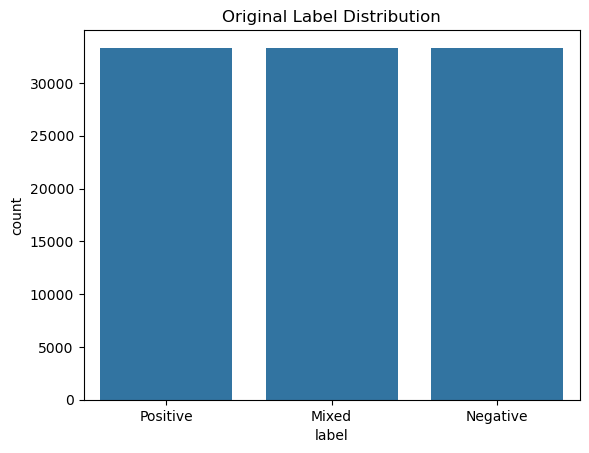

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df["label"].value_counts())

sns.countplot(x="label", data=df)
plt.title("Original Label Distribution")
plt.show()

In [27]:
df = df[df["label"] != "Mixed"]

In [28]:
df["label"] = df["label"].map({
    "Negative": 0,
    "Positive": 1
})

print(df["label"].value_counts())

label
1    33333
0    33333
Name: count, dtype: int64


In [29]:
df.head()

,label,text
0,1,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,1,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,1,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,1,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,1,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


In [30]:
import re

def clean_text(text):

    text = str(text).strip()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

In [31]:
df["clean_text"] = df["text"].apply(clean_text)

In [32]:
train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)

print(len(train_df), len(test_df))
train_dataset = Dataset.from_pandas(train_df[["clean_text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["clean_text", "label"]])


# train_dataset = train_dataset.select(range(2000))
# test_dataset = test_dataset.select(range(500))

59999 6667


In [33]:
MODEL_NAME = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(example):
    return tokenizer(
        example["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
)
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch")
test_dataset.set_format("torch")

Map: 100%|██████████| 6667/6667 [00:00<00:00, 16467.24 examples/s]


In [34]:
NUM_CLIENTS = 3
size = len(train_dataset) // NUM_CLIENTS

client_datasets = []

for i in range(NUM_CLIENTS):

    start = i * size
    end = (i + 1) * size

    client_datasets.append(train_dataset.select(range(start,end)))

In [35]:
def get_parameters(model):
    return [val.cpu().numpy() for _, val in model.state_dict().items()]


def set_parameters(model, parameters):

    params_dict = zip(model.state_dict().keys(), parameters)

    state_dict = {
        k: torch.tensor(v) for k, v in params_dict
    }

    model.load_state_dict(state_dict, strict=True)

In [36]:
def train(model, dataset):

    training_args = TrainingArguments(
        output_dir="./client",
        per_device_train_batch_size=8,
        num_train_epochs=1,
        logging_steps=10,
        save_strategy="no"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset
    )

    trainer.train()

    return model

In [37]:
class FlowerClient(fl.client.NumPyClient):

    def __init__(self, dataset):

        self.model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=2
        )

        self.dataset = dataset


    def get_parameters(self, config):
        return get_parameters(self.model)


    def fit(self, parameters, config):

        set_parameters(self.model, parameters)

        self.model = train(self.model, self.dataset)

        return get_parameters(self.model), len(self.dataset), {}


    def evaluate(self, parameters, config):

        set_parameters(self.model, parameters)

        trainer = Trainer(model=self.model)

        results = trainer.evaluate(test_dataset)

        loss = results["eval_loss"]

        return float(loss), len(test_dataset), {}

In [38]:
def client_fn(cid):

    cid = int(cid)

    dataset = client_datasets[cid]

    return FlowerClient(dataset)

In [ ]:
import flwr as fl
import torch
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# -------------------------
# 1️⃣ Metrics function
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    precision = precision_score(labels, predictions, average="weighted")
    recall = recall_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# -------------------------
# 2️⃣ Train function
# -------------------------
def train(model, dataset):
    training_args = TrainingArguments(
        output_dir="./client",
        per_device_train_batch_size=8,
        num_train_epochs=1,
        logging_steps=10,
        save_strategy="no",
        eval_strategy="epoch"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        compute_metrics=compute_metrics,
        eval_dataset=test_dataset    # pass evaluation dataset

    )

    trainer.train()
    metrics = trainer.evaluate(test_dataset)  # local evaluation
    return model, metrics

# -------------------------
# 3️⃣ Helper functions for Flower
# -------------------------
def get_parameters(model):
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = {k: torch.tensor(v) for k, v in params_dict}
    model.load_state_dict(state_dict, strict=True)

# -------------------------
# 4️⃣ Flower Client
# -------------------------
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, dataset):
        self.model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=2
        )
        self.dataset = dataset

    def get_parameters(self, config=None):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)

        training_args = TrainingArguments(
            output_dir="./client",
            per_device_train_batch_size=8,
            num_train_epochs=1,
            logging_steps=10,
            save_strategy="no",
            eval_strategy="no"  # don't evaluate during training
        )

        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=self.dataset,
        )

        trainer.train()

        # Evaluate locally after training
        eval_trainer = Trainer(
            model=self.model,
            compute_metrics=compute_metrics,
            eval_dataset=test_dataset  # must be separate validation/test dataset
        )

        metrics = eval_trainer.evaluate()
        return get_parameters(self.model), len(self.dataset), metrics

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)

        eval_trainer = Trainer(
            model=self.model,
            compute_metrics=compute_metrics,
            eval_dataset=test_dataset
        )
        metrics = eval_trainer.evaluate()
        return metrics["eval_loss"], len(test_dataset), metrics

# -------------------------
# 5️⃣ Split dataset into clients
# -------------------------
NUM_CLIENTS = 3
size = len(train_dataset) // NUM_CLIENTS
client_datasets = []

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size
    client_datasets.append(train_dataset.select(range(start, end)))

# -------------------------
# 6️⃣ Metrics aggregation
# -------------------------
metrics_history = []

def aggregate_metrics(metrics_list):

    # extract metrics dict
    metrics_only = [m[1] for m in metrics_list]

    agg = {
        "accuracy": sum(m["eval_accuracy"] for m in metrics_only) / len(metrics_only),
        "f1": sum(m["eval_f1"] for m in metrics_only) / len(metrics_only),
        "precision": sum(m["eval_precision"] for m in metrics_only) / len(metrics_only),
        "recall": sum(m["eval_recall"] for m in metrics_only) / len(metrics_only),
        "loss": sum(m["eval_loss"] for m in metrics_only) / len(metrics_only)
    }

    metrics_history.append(agg)
    return agg

# -------------------------
# 7️⃣ Flower strategy
# -------------------------
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,          # train all clients each round
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    fit_metrics_aggregation_fn=aggregate_metrics
)

# -------------------------
# 8️⃣ Client function
# -------------------------
def client_fn(cid):
    cid = int(cid)
    return FlowerClient(client_datasets[cid]).to_client()

# -------------------------
# 9️⃣ Start simulation (parallel)
# -------------------------
fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=3),
    strategy=strategy,
    client_resources={"num_cpus": 2},
    ray_init_args={"num_cpus": NUM_CLIENTS}  # all clients run in parallel
)

# -------------------------
# 10️⃣ Save metrics to CSV
# -------------------------
import csv

keys = metrics_history[0].keys()
with open("federated_metrics.csv", "w", newline="") as f:
    dict_writer = csv.DictWriter(f, keys)
    dict_writer.writeheader()
    dict_writer.writerows(metrics_history)

print("Federated metrics saved to federated_metrics.csv")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=3, no round_timeout
2026-03-09 13:57:55,644	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'accelerator_type:RTX': 1.0, 'GPU': 1.0, 'memory': 12772094362.0, 'node:__internal_head__': 1.0, 'object_store_memory': 5473754726.0, 'node:127.0.0.1': 1.0, 'CPU': 3.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2}
INFO :      Flower VCE: Creating 

(ClientAppActor pid=25848) {'loss': '0.6687', 'grad_norm': '10.87', 'learning_rate': '4.982e-05', 'epoch': '0.004'}


  1%|          | 21/2500 [00:01<02:55, 14.14it/s]


(ClientAppActor pid=25848) {'loss': '0.6367', 'grad_norm': '14.19', 'learning_rate': '4.962e-05', 'epoch': '0.008'}


  1%|          | 31/2500 [00:02<02:54, 14.14it/s]


...

 14%|█▎        | 341/2500 [00:25<02:30, 14.31it/s]


(ClientAppActor pid=25848) {'loss': '0.3762', 'grad_norm': '3.376', 'learning_rate': '4.322e-05', 'epoch': '0.136'}


 14%|█▍        | 351/2500 [00:26<02:30, 14.28it/s]


(ClientAppActor pid=25848) {'loss': '0.2515', 'grad_norm': '88.98', 'learning_rate': '4.302e-05', 'epoch': '0.14'}


 14%|█▍        | 357/2500 [00:27<02:30, 14.25it/s]


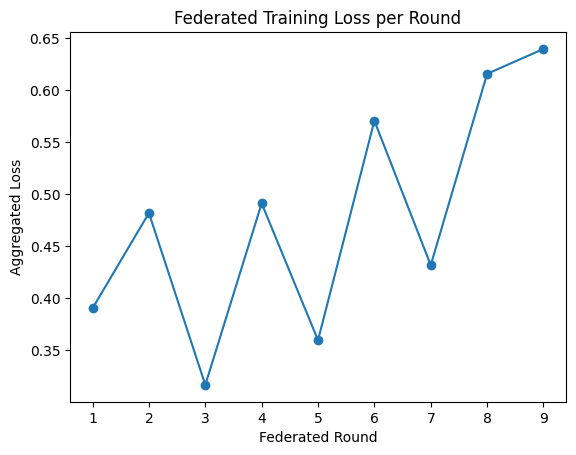

In [23]:
import matplotlib.pyplot as plt

loss_history = [0.3904971480369568, 0.48197704553604126, 0.3168524205684662,
                0.4912731647491455, 0.3597870469093323, 0.5706242918968201,
                0.4318854510784149, 0.6156867742538452, 0.6396107077598572]

plt.plot(range(1, 10), loss_history, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Aggregated Loss")
plt.title("Federated Training Loss per Round")
plt.show()

In [24]:
train_dataset.shape

(2000, 6)

In [25]:
test_dataset.shape

(500, 6)

## 2nd try 


In [ ]:
import flwr as fl
import torch
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# -------------------------
# 1️⃣ Metrics function
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    precision = precision_score(labels, predictions, average="weighted")
    recall = recall_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# -------------------------
# 2️⃣ Train function
# -------------------------
def train(model, dataset):
    training_args = TrainingArguments(
        output_dir="./client",
        per_device_train_batch_size=8,
        num_train_epochs=1,
        logging_steps=10,
        save_strategy="no",
        eval_strategy="no"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        compute_metrics=compute_metrics


    )

    trainer.train()
    metrics = trainer.evaluate(test_dataset)

    return model, {
        "accuracy": metrics["eval_accuracy"],
        "f1": metrics["eval_f1"],
        "precision": metrics["eval_precision"],
        "recall": metrics["eval_recall"],
        "loss": metrics["eval_loss"]
    }

# -------------------------
# 3️⃣ Helper functions for Flower
# -------------------------
def get_parameters(model):
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = {k: torch.tensor(v) for k, v in params_dict}
    model.load_state_dict(state_dict, strict=True)

# -------------------------
# 4️⃣ Flower Client
# -------------------------
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, dataset):
        self.model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=2
        )
        self.dataset = dataset

    def get_parameters(self, config=None):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        self.model, metrics = train(self.model, self.dataset)
        return get_parameters(self.model), len(self.dataset), metrics

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        _, metrics = train(self.model, self.dataset)
        return metrics["loss"], len(self.dataset), metrics

# -------------------------
# 5️⃣ Split dataset into clients
# -------------------------
NUM_CLIENTS = 3
size = len(train_dataset) // NUM_CLIENTS
client_datasets = []

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size
    client_datasets.append(train_dataset.select(range(start, end)))

# -------------------------
# 6️⃣ Metrics aggregation
# -------------------------
metrics_history = []

def aggregate_metrics(metrics_list):
    agg = {
        "accuracy": sum(metrics["accuracy"] for _, metrics in metrics_list) / len(metrics_list),
        "f1": sum(metrics["f1"] for _, metrics in metrics_list) / len(metrics_list),
        "precision": sum(metrics["precision"] for _, metrics in metrics_list) / len(metrics_list),
        "recall": sum(metrics["recall"] for _, metrics in metrics_list) / len(metrics_list),
        "loss": sum(metrics["loss"] for _, metrics in metrics_list) / len(metrics_list)
    }

    metrics_history.append(agg)
    return agg
# -------------------------
# 7️⃣ Flower strategy
# -------------------------
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,          # train all clients each round
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    fit_metrics_aggregation_fn=aggregate_metrics
)

# -------------------------
# 8️⃣ Client function
# -------------------------
def client_fn(cid):
    cid = int(cid)
    return FlowerClient(client_datasets[cid])

# -------------------------
# 9️⃣ Start simulation (parallel)
# -------------------------
fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=1),
    strategy=strategy,
    client_resources={"num_cpus": 1},
    ray_init_args={"num_cpus": NUM_CLIENTS}  # all clients run in parallel
)



	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=9, no round_timeout
2026-03-09 13:52:33,874	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 5714493849.0, 'GPU': 1.0, 'memory': 13333818983.0, 'node:__internal_head__': 1.0, 'accelerator_type:RTX': 1.0, 'node:127.0.0.1': 1.0, 'CPU': 3.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating 

(ClientAppActor pid=7560) {'loss': '0.7412', 'grad_norm': '8.95', 'learning_rate': '4.464e-05', 'epoch': '0.119'}


 25%|██▌       | 21/84 [00:01<00:04, 14.16it/s]


(ClientAppActor pid=7560) {'loss': '0.7018', 'grad_norm': '4.314', 'learning_rate': '3.869e-05', 'epoch': '0.2381'}


 37%|███▋      | 31/84 [00:02<00:03, 14.34it/s]


...

(ClientAppActor pid=7560) {'loss': '0.598', 'grad_norm': '15.78', 'learning_rate': '2.976e-06', 'epoch': '0.9524'}


100%|██████████| 84/84 [00:06<00:00, 13.42it/s]


(ClientAppActor pid=7560) {'train_runtime': '6.26', 'train_samples_per_second': '106.4', 'train_steps_per_second': '13.42', 'train_loss': '0.6339', 'epoch': '1'}
(ClientAppActor pid=21452) {'loss': '0.638', 'grad_norm': '6.621', 'learning_rate': '4.464e-05', 'epoch': '0.119'}


 92%|█████████▏| 58/63 [00:02<00:00, 18.28it/s]
(ClientAppActor pid=28892) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=28892)             This is a deprecated feature. It will be removed
(ClientAppActor pid=28892)             entirely in future versions of Flower.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15307.96it/s]
(ClientAppActor pid=28892) BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
(ClientAppActor pid=28892) Key                                        | Status     | 
(ClientAppActor pid=28892) -------------------------------------------+------------+-
(ClientAppActor pid=28892) cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
(ClientAppActor pid=28892) cls.predictions.transform.dense.weight     | UNEXPECT

(ClientAppActor pid=28892) {'loss': '0.6828', 'grad_norm': '3.228', 'learning_rate': '3.274e-05', 'epoch': '0.3571'} [repeated 5x across cluster]


In [ ]:
# -------------------------
# 10️⃣ Save metrics to CSV
# -------------------------
import csv

keys = metrics_history[0].keys()
with open("federated_metrics.csv", "w", newline="") as f:
    dict_writer = csv.DictWriter(f,  keys)
    dict_writer.writeheader()
    dict_writer.writerows(metrics_history)

print("Federated metrics saved to federated_metrics.csv")